# Battery scheduling with rainflow wear

Run **Runtime → Run all** in Google Colab, or **Run All Cells** in Jupyter. This notebook is self-contained and uses NumPy, SciPy (version 1.9 or later), pandas, and Matplotlib. Every answer is calculated when its cell runs; only the supplied prices and battery parameters are fixed inputs. The saved outputs come from a complete execution of these cells.

The calculation proceeds as follows:

1. Reproduce the supplied rainflow counter, feasibility check, cash-flow calculation, and Amp's LP benchmark.
2. Optimize each of the seven days using supporting planes to the convex rainflow wear function. A mixed-integer linear master provides a global profit upper bound, while the exact scorer evaluates a feasible schedule. Negative-price slots have binary charge/discharge modes to exclude simultaneous operation. Stop when the numerical upper bound and feasible profit differ by at most `OPTIMALITY_TOL` dollars per battery-day.
3. Calculate the Day 1 answer, all seven schedules, feasibility checks, optimality gaps, and annual fleet profit. Annualization uses 12 batteries and (365/7) times the seven-day total, assuming representative prices, full availability, and the puzzle's daily rainflow accounting.
4. Keep the exponent-2 schedules and Amp's schedules fixed, then rescore both as the true wear exponent varies from 1.5 to 2.5. Bound the derivative of the profit difference on every subinterval to check the full range. Reoptimize at the two endpoint exponents as well. Since normalized cycle depths lie in ([0,1]), exponent 1.5 is the worst case for absolute profit; its optimum is also the maximin schedule over this interval.
5. Calculate a separate 365-day replay with one continuous rainflow count. Daily rainflow costs need not add across midnight, even when SOC returns to 50 MWh. The replay evaluates the daily schedules; it does not optimize a full annual horizon or estimate an asset's discounted value.

All certificates are numerical and subject to floating-point and solver tolerances. The solver moves candidates slightly toward constant SOC to remove numerical feasibility violations.

Sources: [original puzzle and data](https://colab.research.google.com/drive/1WWEgG3tyQ5Ybo_3kjfQHYgMwJg6po9Qz) · [convexity of rainflow cycle cost](https://arxiv.org/abs/1703.07968).


In [1]:
from collections import deque
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import Bounds, LinearConstraint, brentq, linprog, milp
from scipy.sparse import csr_matrix

pd.set_option("display.max_rows", 60)
pd.set_option("display.max_columns", 12)
pd.set_option("display.float_format", "{:,.6f}".format)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "text.parse_math": False})

P_MAX = 50.0
CAP = 100.0
ETA_C = ETA_D = 0.95
DT = 0.5
T = 48
SOC0 = 50.0
BETA = 2.0
C_FULL = 3000.0
MAX_UP = P_MAX * DT * ETA_C
MAX_DOWN = P_MAX * DT / ETA_D

FLEET_SIZE = 12
DAYS_PER_YEAR = 365
OPTIMALITY_TOL = 0.001
EXPONENT_MIN, EXPONENT_MAX = 1.5, 2.5

def show_table(title, table, decimals=2):
    print(title)
    with pd.option_context("display.float_format", f"{{:,.{decimals}f}}".format):
        display(table)

In [2]:
PRICES = np.array([
    # day 1
    [
        32.66, 32.56, 16.34, 4.04, 24.47, 21.60, 40.35, 40.40, 10.79, 17.49, 14.15, 24.32,
        39.25, 60.13, 45.76, 40.19, 40.67, 24.39, 11.59, 105.17, 55.39, -18.98, -2.02,
        -24.09, -23.10, -12.87, -16.67, -2.76, 0.31, 17.37, 17.20, 70.79, 40.33, 47.29,
        57.49, 78.36, 103.47, 114.05, 131.83, 136.05, 127.52, 180.44, 81.74, 59.13, 64.17,
        68.12, 31.84, 59.19,
    ],
    # day 2
    [
        29.40, 35.93, 28.06, 43.57, 38.71, 47.19, 34.96, 0.97, 2.11, 7.46, 32.37, 41.50,
        49.40, 46.48, 59.28, 71.40, 55.84, 48.90, 8.89, 14.48, 1.62, 3.97, 4.74, -1.84,
        -6.21, 1.72, 2.47, -19.40, 10.93, 15.50, 5.41, 14.91, 43.94, 41.24, 86.25, 102.31,
        101.69, 116.63, 129.57, 110.50, 150.11, 76.43, 67.41, 117.31, 43.03, 36.85, 39.48,
        43.03,
    ],
    # day 3
    [
        37.56, 32.37, 37.14, 72.91, 35.84, 51.35, 32.36, 23.99, 46.82, 40.27, 22.03, 48.77,
        60.14, 77.97, 112.55, 83.78, 62.91, 55.37, 34.81, 15.94, -4.26, -6.83, -23.17,
        -8.52, -23.39, -17.25, -32.43, -8.27, 1.40, 14.52, 14.22, -0.55, 43.70, 47.25,
        77.07, 57.74, 71.32, 107.95, 132.07, 148.24, 135.49, 124.02, 117.08, 95.88, 91.66,
        81.85, 48.64, 48.83,
    ],
    # day 4
    [
        26.13, 31.44, 27.57, 48.35, 21.62, 3.77, 7.79, 12.99, 27.74, 30.18, 11.86, 22.06,
        106.03, 10.96, 40.90, 64.04, 54.88, 36.57, 26.53, 33.15, 2.78, 10.61, 10.74, 13.76,
        11.53, 18.75, 10.61, 8.18, 10.24, 24.45, 7.63, 25.10, 29.36, 71.57, 76.66, 79.72,
        81.10, 94.67, 86.38, 90.67, 77.12, 86.45, 88.56, 58.68, 61.83, 44.73, 47.29, 18.97,
    ],
    # day 5
    [
        34.30, 31.62, 42.59, 33.62, 25.35, 43.42, 32.87, 31.13, 11.13, 27.03, 109.55, 30.42,
        59.08, 60.40, 92.19, 104.23, 53.55, 53.51, 23.75, 32.10, 26.79, -19.92, -5.09,
        -5.15, -5.23, 3.56, -24.99, 11.74, 32.99, 32.78, 10.64, 65.02, 58.49, 77.05, 115.81,
        130.30, 153.75, 132.69, 136.35, 107.53, 99.82, 104.32, 54.90, 75.36, 44.93, 47.75,
        43.00, 55.31,
    ],
    # day 6
    [
        22.86, 28.30, 41.97, 29.68, 33.16, 91.65, 19.62, 23.79, 29.82, 94.21, 61.16, 51.27,
        34.73, 33.95, 40.31, 41.31, 25.16, 38.00, 3.21, -3.70, 4.10, -6.88, -30.44, 0.04,
        -19.96, 15.88, 12.88, -17.93, 12.84, 23.12, -11.23, 2.91, 39.60, 65.29, 27.53,
        43.40, 31.47, 38.95, 64.91, 67.21, 83.72, 86.11, 70.05, 74.08, 45.12, 125.42, 43.20,
        14.57,
    ],
    # day 7
    [
        31.03, 20.02, 16.66, 27.25, 34.41, 14.82, 14.59, 36.31, 22.16, 12.46, 34.46, 22.75,
        21.00, 47.22, 65.09, 67.78, 52.64, 51.82, 32.14, 17.90, -11.22, 23.91, 13.20, 9.12,
        22.69, 6.02, -26.94, -24.43, -8.53, -9.09, 21.46, 20.70, 40.00, 60.87, 75.88, 89.29,
        163.76, 101.66, 138.72, 125.85, 111.73, 82.73, 178.39, 95.58, 60.69, 62.10, 41.29,
        24.46,
    ],
])

In [3]:
def prices_for(day):
    """Prices of day 1..7 as an array of 48 values."""
    if not 1 <= day <= 7:
        raise ValueError("day must be between 1 and 7")
    return PRICES[day - 1]


def _reversals(series, tol=1e-9):
    """End points and turning points of a series (repeated values are dropped)."""
    s = [series[0]]
    for v in series[1:]:
        if abs(v - s[-1]) > tol:
            s.append(v)
    if len(s) < 3:
        return s
    out = [s[0]]
    for i in range(1, len(s) - 1):
        if (s[i] - s[i - 1]) * (s[i + 1] - s[i]) < 0:
            out.append(s[i])
    out.append(s[-1])
    return out


def rainflow_cycles(series):
    """Returns a list of (range, count) with count 1.0 (full cycle) or 0.5 (half cycle)."""
    pts, res = deque(), []
    for p in _reversals(list(series)):
        pts.append(p)
        while len(pts) >= 3:
            x = abs(pts[-2] - pts[-1])
            y = abs(pts[-3] - pts[-2])
            if x < y:
                break
            if len(pts) == 3:                        # Y contains the start point: half cycle
                res.append((y, 0.5))
                pts.popleft()
            else:                                    # closed cycle
                res.append((y, 1.0))
                last = pts.pop(); pts.pop(); pts.pop(); pts.append(last)
    pl = list(pts)
    for a, b in zip(pl, pl[1:]):                     # what is left counts as half cycles
        res.append((abs(a - b), 0.5))
    return res


def wear_cost(soc, beta=BETA):
    """Wear in $ of one day's SOC path (49 values): a cycle of range r costs C_FULL*(r/CAP)**beta."""
    return C_FULL * sum(c * (r / CAP) ** beta for r, c in rainflow_cycles(soc))


def revenue(day_prices, soc):
    """Cash flow in $: sell ETA_D*|D| MWh when the SOC drops by |D|, buy D/ETA_C MWh when it rises by D."""
    d = np.diff(np.asarray(soc, float))
    return float(np.sum(day_prices * (ETA_D * np.maximum(0, -d) - np.maximum(0, d) / ETA_C)))


def net_profit(day_prices, soc, beta=BETA):
    return revenue(day_prices, soc) - wear_cost(soc, beta)


def check_feasible(soc, tol=1e-6):
    """Returns a list of problems (empty list = feasible)."""
    soc = np.asarray(soc, float)
    if len(soc) != T + 1:
        return [f"need {T + 1} SOC values, got {len(soc)}"]
    d = np.diff(soc)
    problems = []
    if abs(soc[0] - SOC0) > tol or abs(soc[-1] - SOC0) > tol:
        problems.append("SOC must start and end at 50 MWh")
    if soc.min() < -tol or soc.max() > CAP + tol:
        problems.append("SOC must stay between 0 and 100 MWh")
    if d.max() > MAX_UP + tol:
        problems.append(f"charging too fast: at most +{MAX_UP:.2f} MWh per slot")
    if d.min() < -MAX_DOWN - tol:
        problems.append(f"discharging too fast: at most -{MAX_DOWN:.2f} MWh per slot")
    return problems


def lp_baseline(day_prices, adder=None):
    """Amp's LP: maximize cash flow minus a FLAT wear price per MWh sold.
    Default price = $3000 / (100 MWh * 0.95) = $31.58 per MWh. Returns the SOC path (49 values)."""
    from scipy.optimize import linprog
    if adder is None:
        adder = C_FULL / (CAP * ETA_D)
    n = T
    c = np.concatenate([day_prices * DT, -(day_prices - adder) * DT])   # x = [charge MW (n), discharge MW (n)]
    low = np.tril(np.ones((n, n)))
    a = np.hstack([DT * ETA_C * low, -DT / ETA_D * low])                # SOC after slot t = SOC0 + a @ x
    a_ub = np.vstack([a, -a])
    b_ub = np.concatenate([np.full(n, CAP - SOC0), np.full(n, SOC0)])
    a_eq = np.concatenate([DT * ETA_C * np.ones(n), -DT / ETA_D * np.ones(n)])[None, :]
    res = linprog(c, A_ub=a_ub, b_ub=b_ub, A_eq=a_eq, b_eq=[0.0], bounds=[(0, P_MAX)] * (2 * n), method="highs")
    soc = SOC0 + np.concatenate([[0.0], np.cumsum(DT * (ETA_C * res.x[:n] - res.x[n:] / ETA_D))])
    soc[-1] = SOC0
    return soc


def score(day, soc, label="your schedule"):
    """Checks and scores a schedule for the given day (1..7) and compares it with Amp's LP."""
    p = prices_for(day)
    lp = lp_baseline(p)
    for name, s in (("Amp's LP", lp), (label, soc)):
        problems = check_feasible(s)
        rev, wr = revenue(p, s), wear_cost(s)
        print(f"{name:>14}: cash flow ${rev:>9,.2f}   wear ${wr:>8,.2f}   NET ${rev - wr:>9,.2f}"
              + ("" if not problems else "   <-- INFEASIBLE: " + "; ".join(problems)))
    gain = net_profit(p, soc) - net_profit(p, lp)
    print(f"{'difference':>14}: ${gain:,.2f} per battery and day")

assert abs(wear_cost([50, 90, 70, 100, 50]) - 870.0) < 1e-9
assert PRICES.shape == (7, T)

In [4]:
def make_feasible(soc):
    """Remove numerical constraint violations by moving toward the flat path."""
    s = np.asarray(soc, float).copy()
    s[0] = s[-1] = SOC0
    d = np.diff(s)
    ratios = [1.0]
    if s.max() > SOC0:
        ratios.append((CAP-SOC0)/(s.max()-SOC0))
    if s.min() < SOC0:
        ratios.append(SOC0/(SOC0-s.min()))
    if d.max() > 0:
        ratios.append(MAX_UP/d.max())
    if d.min() < 0:
        ratios.append(MAX_DOWN/(-d.min()))
    return SOC0+(min(ratios)-1e-12)*(s-SOC0)


def indexed_cycles(soc):
    """Same ASTM counter as the source, retaining endpoint indices."""
    s = np.asarray(soc, float)
    ids = [0]
    for i in range(1, len(s)):
        if abs(s[i] - s[ids[-1]]) > 1e-9:
            ids.append(i)
    if len(ids) >= 3:
        ids = [ids[0]] + [b for a, b, c in zip(ids, ids[1:], ids[2:])
                           if (s[b]-s[a])*(s[c]-s[b]) < 0] + [ids[-1]]
    pts, out = deque(), []
    for p in ids:
        pts.append(p)
        while len(pts) >= 3:
            x = abs(s[pts[-2]]-s[pts[-1]])
            y = abs(s[pts[-3]]-s[pts[-2]])
            if x < y:
                break
            if len(pts) == 3:
                out.append((pts[-3], pts[-2], 0.5))
                pts.popleft()
            else:
                out.append((pts[-3], pts[-2], 1.0))
                last = pts.pop(); pts.pop(); pts.pop(); pts.append(last)
    out.extend((a, b, 0.5) for a, b in zip(pts, list(pts)[1:]))
    return out


def wear_subgradient(soc, beta=2.0):
    s = np.asarray(soc, float)
    g = np.zeros_like(s)
    cost = 0.0
    for a, b, count in indexed_cycles(s):
        delta = s[a]-s[b]
        r = abs(delta)/CAP
        cost += C_FULL * count * r**beta
        v = C_FULL * count * beta * r**(beta-1) * np.sign(delta)/CAP
        g[a] += v
        g[b] -= v
    return cost, g

In [5]:
def solve_day(day, beta=BETA, tol=OPTIMALITY_TOL, max_iterations=4000):
    prices = prices_for(day)
    negative_slots = np.flatnonzero(prices < 0)
    n_soc = T + 1
    i_up, i_down = n_soc, n_soc + T
    i_wear, i_mode = n_soc + 2*T, n_soc + 2*T + 1
    n = i_mode + len(negative_slots)

    objective = np.zeros(n)
    objective[i_up:i_down] = prices / ETA_C
    objective[i_down:i_wear] = -prices * ETA_D
    objective[i_wear] = 1.0

    lower = np.zeros(n)
    upper = np.full(n, np.inf)
    upper[:n_soc] = CAP
    lower[0] = upper[0] = lower[T] = upper[T] = SOC0
    upper[i_up:i_down] = MAX_UP
    upper[i_down:i_wear] = MAX_DOWN
    upper[i_mode:] = 1.0
    integer = np.zeros(n, dtype=int)
    integer[i_mode:] = 1

    rows, row_lower, row_upper = [], [], []
    for t in range(T):
        row = np.zeros(n)
        row[t+1], row[t], row[i_up+t], row[i_down+t] = 1, -1, -1, 1
        rows.append(row)
        row_lower.append(0.0)
        row_upper.append(0.0)
    for j, t in enumerate(negative_slots):
        row = np.zeros(n)
        row[i_up+t], row[i_mode+j] = 1, -MAX_UP
        rows.append(row)
        row_lower.append(-np.inf)
        row_upper.append(0.0)
        row = np.zeros(n)
        row[i_down+t], row[i_mode+j] = 1, MAX_DOWN
        rows.append(row)
        row_lower.append(-np.inf)
        row_upper.append(MAX_DOWN)

    def add_supporting_plane(soc):
        cost, gradient = wear_subgradient(soc, beta)
        row = np.zeros(n)
        row[:n_soc], row[i_wear] = gradient, -1.0
        rows.append(row)
        row_lower.append(-np.inf)
        row_upper.append(gradient @ soc - cost)

    best_soc = make_feasible(lp_baseline(prices))
    best_profit = net_profit(prices, best_soc, beta)
    profit_bound = np.inf
    add_supporting_plane(best_soc)
    started = perf_counter()

    for iteration in range(1, max_iterations + 1):
        master = milp(
            objective,
            integrality=integer,
            bounds=Bounds(lower, upper),
            constraints=LinearConstraint(csr_matrix(np.asarray(rows)), row_lower, row_upper),
            options={"mip_rel_gap": 1e-10, "time_limit": 60.0},
        )
        if master.x is None:
            raise RuntimeError(master.message)
        cost_bound = getattr(master, "mip_dual_bound", None)
        if cost_bound is None:
            if not master.success:
                raise RuntimeError(master.message)
            cost_bound = master.fun
        if not np.isfinite(cost_bound):
            raise RuntimeError("The master did not return a finite objective bound.")
        profit_bound = min(profit_bound, -cost_bound)

        raw_soc = master.x[:n_soc]
        candidate = make_feasible(raw_soc)
        candidate_profit = net_profit(prices, candidate, beta)
        if candidate_profit > best_profit:
            best_soc, best_profit = candidate.copy(), candidate_profit
        gap = profit_bound - best_profit
        if gap < -1e-5:
            raise RuntimeError("The numerical upper bound is below the feasible profit.")
        if gap <= tol:
            break
        add_supporting_plane(raw_soc)
    else:
        raise RuntimeError(f"Day {day}, beta={beta}: requested gap not reached.")

    assert not check_feasible(best_soc, tol=1e-9)
    assert abs(wear_subgradient(best_soc, beta)[0] - wear_cost(best_soc, beta)) < 1e-7
    return {
        "day": day, "beta": beta, "soc": best_soc,
        "cash": revenue(prices, best_soc), "wear": wear_cost(best_soc, beta),
        "net": best_profit, "upper_bound": profit_bound, "gap": max(0.0, gap),
        "iterations": iteration, "seconds": perf_counter() - started,
    }

In [6]:
DAYS = range(1, len(PRICES) + 1)
BASELINE = {day: lp_baseline(prices_for(day)) for day in DAYS}
RESULTS = {}
for day in DAYS:
    RESULTS[day] = solve_day(day)
    print(f"Day {day} solved: gap ${RESULTS[day]['gap']:.6f}")

SCHEDULES = {day: result["soc"] for day, result in RESULTS.items()}
daily = pd.DataFrame([
    {
        "Day": day,
        "Amp net ($)": net_profit(prices_for(day), BASELINE[day], BETA),
        "Optimized cash ($)": RESULTS[day]["cash"],
        "Wear ($)": RESULTS[day]["wear"],
        "Optimized net ($)": RESULTS[day]["net"],
        "Gain ($)": RESULTS[day]["net"] - net_profit(prices_for(day), BASELINE[day], BETA),
    }
    for day in DAYS
]).set_index("Day")
show_table("Daily results per battery", daily)

certificates = pd.DataFrame([
    {"Day": day, "Feasible profit ($)": r["net"],
     "Global upper bound ($)": r["upper_bound"], "Gap ($)": r["gap"],
     "Feasible": not check_feasible(r["soc"], tol=1e-9)}
    for day, r in RESULTS.items()
]).set_index("Day")
show_table("Numerical optimality certificates", certificates, decimals=6)

Day 1 solved: gap $0.000859
Day 2 solved: gap $0.000966
Day 3 solved: gap $0.000915
Day 4 solved: gap $0.000995
Day 5 solved: gap $0.000984
Day 6 solved: gap $0.000999
Day 7 solved: gap $0.000992
Daily results per battery


,Amp net ($),Optimized cash ($),Wear ($),Optimized net ($),Gain ($)
Day,,,,,
1,"14,505.46","21,255.91","5,118.89","16,137.01","1,631.55"
2,"12,177.83","17,964.65","5,379.97","12,584.69",406.86
3,"15,067.53","20,843.71","5,027.11","15,816.60",749.08
4,"7,941.42","12,484.37","3,397.33","9,087.04","1,145.61"
5,"14,923.31","21,272.97","5,000.04","16,272.93","1,349.62"
6,"11,790.56","17,463.16","4,176.94","13,286.22","1,495.66"
7,"14,932.47","21,111.69","5,108.71","16,002.97","1,070.50"


Numerical optimality certificates


,Feasible profit ($),Global upper bound ($),Gap ($),Feasible
Day,,,,
1,"16,137.012976","16,137.013835",0.000859,True
2,"12,584.685332","12,584.686298",0.000966,True
3,"15,816.602607","15,816.603522",0.000915,True
4,"9,087.038516","9,087.039511",0.000995,True
5,"16,272.928348","16,272.929332",0.000984,True
6,"13,286.223858","13,286.224857",0.000999,True
7,"16,002.971820","16,002.972811",0.000992,True


In [7]:
my_soc = SCHEDULES[1].copy()
score(1, my_soc)
print("\nmy_soc = [")
for start in range(0, len(my_soc), 7):
    print("    " + ", ".join(f"{v:.9f}" for v in my_soc[start:start+7]) + ",")
print("]")

soc_table = pd.DataFrame(
    {f"Day {day}": SCHEDULES[day] for day in DAYS},
    index=[f"{t//2:02d}:{30*(t%2):02d}" for t in range(T+1)],
)
soc_table.index.name = "Boundary time"
show_table("SOC schedules (MWh)", soc_table, decimals=6)

      Amp's LP: cash flow $19,662.91   wear $5,157.45   NET $14,505.46
 your schedule: cash flow $21,255.91   wear $5,118.89   NET $16,137.01
    difference: $1,631.55 per battery and day

my_soc = [
    50.000000000, 31.796815019, 31.796814582, 35.946819630, 59.696819630, 58.852475577, 59.696809755,
    46.946271845, 20.630482371, 44.380482371, 41.512954167, 59.696872903, 59.696868484, 59.696868484,
    33.381079011, 22.950899277, 22.950899277, 22.950891504, 28.881578947, 52.631578947, 26.315789474,
    0.000000000, 23.750000000, 5.000000000, 28.750000000, 52.500000000, 76.250000000, 100.000000000,
    100.000000000, 99.999998293, 99.999998293, 100.000000000, 73.684210526, 97.434210526, 100.000000000,
    100.000000000, 100.000000000, 100.000000000, 100.000000000, 73.684210526, 47.368421053, 26.315789474,
    0.000000000, 0.000000000, 23.750000000, 23.750000000, 19.737651251, 43.487651251, 50.000000000,
]
SOC schedules (MWh)


,Day 1,Day 2,Day 3,Day 4,Day 5,Day 6,Day 7
Boundary time,,,,,,,
00:00,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
00:30,31.796815,50.000062,50.000000,60.931655,50.000000,67.354058,42.380243
01:00,31.796815,42.344501,73.750000,59.533084,59.430591,67.354058,42.380243
01:30,35.946820,50.000037,73.750000,60.931690,44.960270,52.963886,66.130243
02:00,59.696820,37.127819,47.434211,34.615901,44.960270,67.354051,66.130243
02:30,58.852476,38.199614,65.862970,34.615893,68.710270,67.354051,42.380223
03:00,59.696810,11.883824,47.434209,58.365893,47.164619,41.038262,57.298994
03:30,46.946272,11.883817,48.795132,82.115893,47.164619,64.788262,81.048994
04:00,20.630482,35.633817,72.545132,89.813210,47.164619,67.354052,57.298998


In [8]:
annual_factor = FLEET_SIZE * DAYS_PER_YEAR / len(PRICES)
week_amp = daily["Amp net ($)"].sum()
week_optimized = daily["Optimized net ($)"].sum()
annual = pd.DataFrame({
    "Amp LP": [week_amp, week_amp * annual_factor],
    "Optimized": [week_optimized, week_optimized * annual_factor],
}, index=["Seven-day net per battery ($)", "Annualized fleet net ($)"])
annual["Gain ($)"] = annual["Optimized"] - annual["Amp LP"]
annual["Gain (%)"] = 100 * annual["Gain ($)"] / annual["Amp LP"]
show_table("Annualization using daily rainflow scoring", annual)

Annualization using daily rainflow scoring


,Amp LP,Optimized,Gain ($),Gain (%)
Seven-day net per battery ($),"91,338.57","99,187.46","7,848.89",8.59
Annualized fleet net ($),"57,151,849.08","62,063,012.85","4,911,163.77",8.59


In [9]:
def fleet_net(schedules, beta):
    return annual_factor * sum(
        net_profit(prices_for(day), schedules[day], beta) for day in DAYS
    )

exponents = np.linspace(EXPONENT_MIN, EXPONENT_MAX, 101)
sensitivity = pd.DataFrame({
    "True exponent": exponents,
    "Fixed nominal schedules ($/year)": [fleet_net(SCHEDULES, beta) for beta in exponents],
    "Amp LP ($/year)": [fleet_net(BASELINE, beta) for beta in exponents],
}).set_index("True exponent")
sensitivity["Gain ($/year)"] = (
    sensitivity["Fixed nominal schedules ($/year)"] - sensitivity["Amp LP ($/year)"]
)
show_table("Sensitivity with both schedules held fixed", sensitivity.iloc[::25])

def cycle_arrays(soc):
    cycles = [(r/CAP, count) for r, count in rainflow_cycles(soc) if r > 0]
    q, c = np.array(cycles).T
    assert np.max(q) <= 1 + 1e-12
    return np.clip(q, 0, 1), c

intervals = np.linspace(EXPONENT_MIN, EXPONENT_MAX, 1001)
robustness_rows = []
for day in DAYS:
    q, count = cycle_arrays(SCHEDULES[day])
    q0, count0 = cycle_arrays(BASELINE[day])
    derivative_lower_bound = min(
        C_FULL * (np.sum(count * (-np.log(q)) * q**b)
                  - np.sum(count0 * (-np.log(q0)) * q0**a))
        for a, b in zip(intervals[:-1], intervals[1:])
    )
    assert derivative_lower_bound > 0, "Continuous monotonicity not certified."
    gain = lambda beta: (
        net_profit(prices_for(day), SCHEDULES[day], beta)
        - net_profit(prices_for(day), BASELINE[day], beta)
    )
    crossing = (brentq(gain, EXPONENT_MIN, EXPONENT_MAX)
                if gain(EXPONENT_MIN) * gain(EXPONENT_MAX) < 0 else np.nan)
    robustness_rows.append({
        "Day": day,
        "Derivative lower bound ($)": derivative_lower_bound,
        "Minimum gain in interval ($)": gain(EXPONENT_MIN),
        "Break-even exponent": crossing,
    })
robustness = pd.DataFrame(robustness_rows).set_index("Day")
show_table("Continuous-interval comparison per battery-day", robustness, decimals=6)
print(f"Minimum weekly gain over the full interval: "
      f"${robustness['Minimum gain in interval ($)'].sum():,.2f} per battery")
print(f"Minimum annualized fleet gain over the full interval: "
      f"${annual_factor * robustness['Minimum gain in interval ($)'].sum():,.2f}")

Sensitivity with both schedules held fixed


,Fixed nominal schedules ($/year),Amp LP ($/year),Gain ($/year)
True exponent,,,
1.50,"56,057,638.37","54,895,813.16","1,161,825.21"
1.75,"59,520,375.71","56,152,182.21","3,368,193.49"
2.00,"62,063,012.85","57,151,849.08","4,911,163.77"
2.25,"63,970,038.66","57,960,531.06","6,009,507.60"
2.50,"65,429,914.54","58,623,956.75","6,805,957.79"


Continuous-interval comparison per battery-day


,Derivative lower bound ($),Minimum gain in interval ($),Break-even exponent
Day,,,
1,772.757766,656.435251,NaN
2,468.230818,-59.471068,1.548441
3,329.786093,92.131206,NaN
4,686.662465,289.238380,NaN
5,623.958558,349.979884,NaN
6,662.039201,463.047550,NaN
7,801.277943,65.437081,NaN


Minimum weekly gain over the full interval: $1,856.80 per battery
Minimum annualized fleet gain over the full interval: $1,161,825.21


In [10]:
ENDPOINT_RESULTS = {}
for beta in (EXPONENT_MIN, EXPONENT_MAX):
    ENDPOINT_RESULTS[beta] = {day: solve_day(day, beta=beta) for day in DAYS}
    print(f"Reoptimized all days at beta={beta:g}")

reoptimized_rows = []
for beta, result_set in (
    (EXPONENT_MIN, ENDPOINT_RESULTS[EXPONENT_MIN]),
    (BETA, RESULTS),
    (EXPONENT_MAX, ENDPOINT_RESULTS[EXPONENT_MAX]),
):
    reoptimized = annual_factor * sum(r["net"] for r in result_set.values())
    fixed = fleet_net(SCHEDULES, beta)
    reoptimized_rows.append({
        "True exponent": beta,
        "Reoptimized fleet net ($/year)": reoptimized,
        "Fixed nominal fleet net ($/year)": fixed,
        "Cost of mismatch ($/year)": reoptimized - fixed,
        "Maximum daily gap ($)": max(r["gap"] for r in result_set.values()),
    })
show_table("Reoptimization at the true exponent", pd.DataFrame(reoptimized_rows).set_index("True exponent"))

MAXIMIN_SCHEDULES = {day: r["soc"] for day, r in ENDPOINT_RESULTS[EXPONENT_MIN].items()}
maximin = pd.DataFrame({
    "True exponent": [EXPONENT_MIN, BETA, EXPONENT_MAX],
    "Maximin fleet net ($/year)": [fleet_net(MAXIMIN_SCHEDULES, beta)
                                 for beta in (EXPONENT_MIN, BETA, EXPONENT_MAX)],
}).set_index("True exponent")
show_table("One fixed schedule optimized for the worst exponent", maximin)

Reoptimized all days at beta=1.5
Reoptimized all days at beta=2.5
Reoptimization at the true exponent


,Reoptimized fleet net ($/year),Fixed nominal fleet net ($/year),Cost of mismatch ($/year),Maximum daily gap ($)
True exponent,,,,
1.50,"57,000,651.36","56,057,638.37","943,012.99",0.00
2.00,"62,063,012.85","62,063,012.85",0.00,0.00
2.50,"65,791,850.00","65,429,914.54","361,935.45",0.00


One fixed schedule optimized for the worst exponent


,Maximin fleet net ($/year)
True exponent,
1.50,"57,000,651.36"
2.00,"61,260,220.33"
2.50,"63,710,768.16"


In [11]:
def replay_year(schedules, beta=BETA):
    history = [SOC0]
    cash, reset_wear = 0.0, 0.0
    for calendar_day in range(DAYS_PER_YEAR):
        day = calendar_day % len(PRICES) + 1
        soc = schedules[day]
        history.extend(soc[1:])
        cash += revenue(prices_for(day), soc)
        reset_wear += wear_cost(soc, beta)
    continuous_wear = wear_cost(history, beta)
    return {
        "Trading cash ($)": FLEET_SIZE * cash,
        "Net with daily reset ($)": FLEET_SIZE * (cash - reset_wear),
        "Net with continuous rainflow ($)": FLEET_SIZE * (cash - continuous_wear),
    }

replay = pd.DataFrame({"Amp LP": replay_year(BASELINE),
                       "Optimized daily schedules": replay_year(SCHEDULES)}).T
show_table(f"Fleet replay: {DAYS_PER_YEAR} days in the order 1, 2, ..., 7, 1, ...", replay)
print(f"Gain under continuous rainflow: "
      f"${replay.loc['Optimized daily schedules', 'Net with continuous rainflow ($)'] - replay.loc['Amp LP', 'Net with continuous rainflow ($)']:,.2f}")

Fleet replay: 365 days in the order 1, 2, ..., 7, 1, ...


,Trading cash ($),Net with daily reset ($),Net with continuous rainflow ($)
Amp LP,"78,672,800.82","57,169,334.17","55,469,171.84"
Optimized daily schedules,"82,870,461.83","62,086,621.35","60,763,227.86"


Gain under continuous rainflow: $5,294,056.01


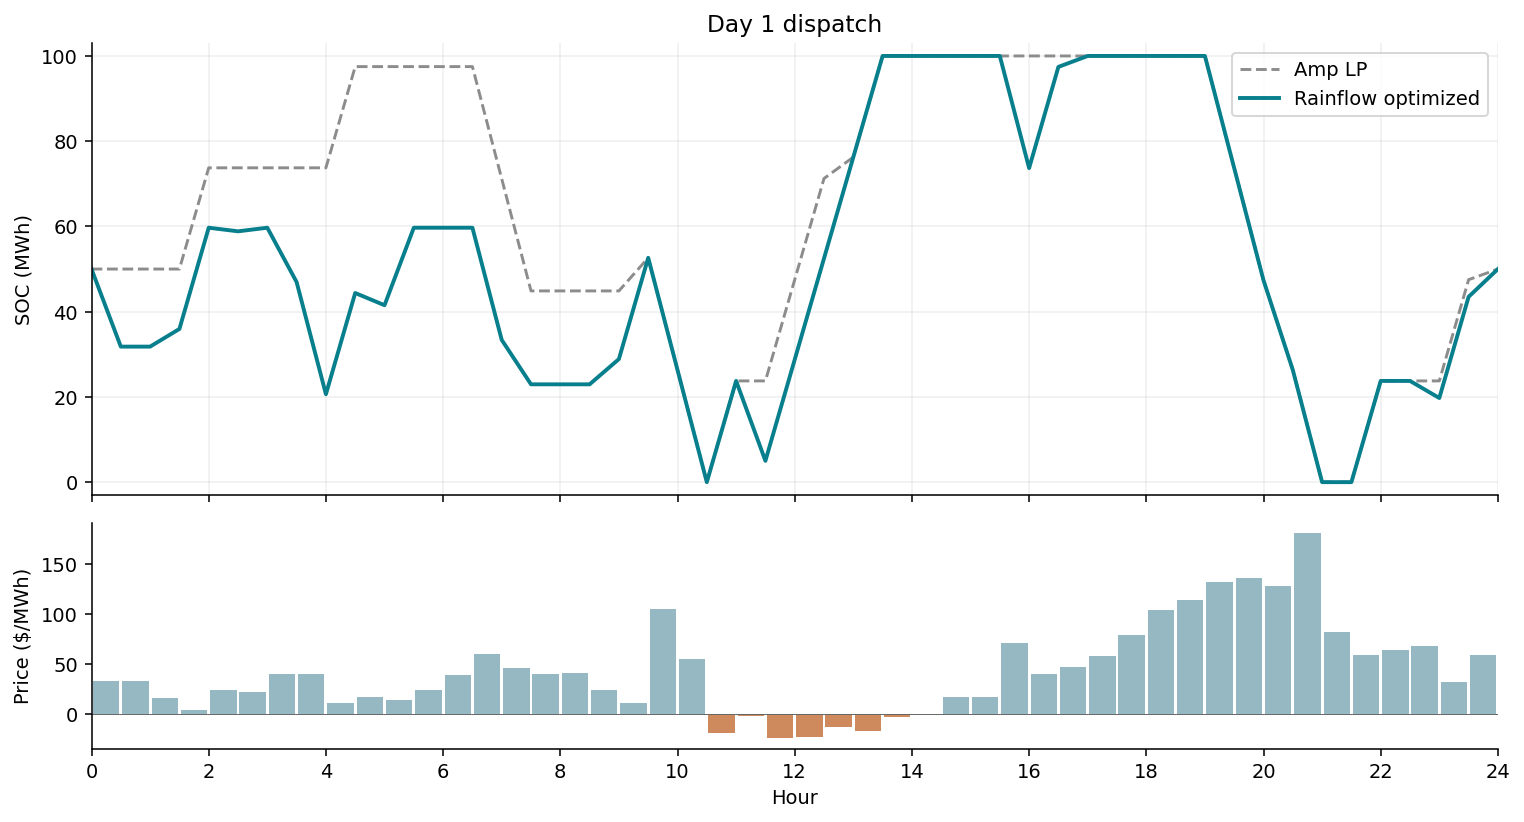

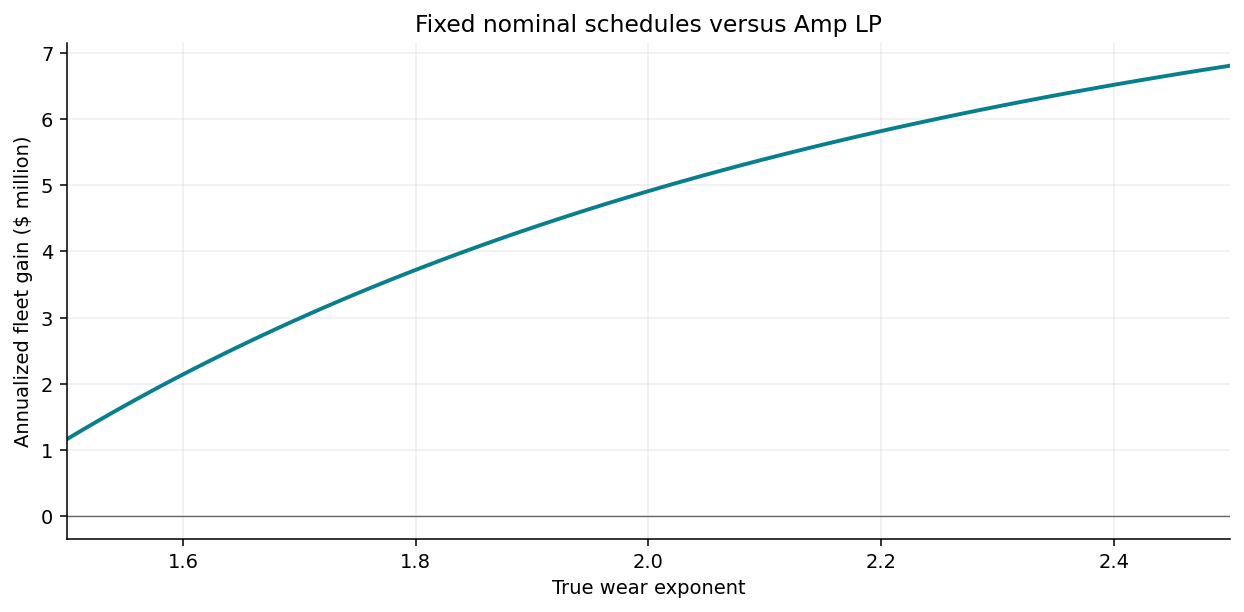

In [12]:
fig, (ax_soc, ax_price) = plt.subplots(
    2, 1, figsize=(11, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)
hours = np.arange(T+1) * DT
ax_soc.plot(hours, BASELINE[1], "--", color="0.55", label="Amp LP")
ax_soc.plot(hours, SCHEDULES[1], color="#087f8c", lw=2, label="Rainflow optimized")
ax_soc.set(ylabel="SOC (MWh)", ylim=(-3, 103), title="Day 1 dispatch")
ax_soc.legend()
ax_soc.grid(alpha=0.2)
ax_price.bar(np.arange(T)*DT + DT/2, prices_for(1), width=DT*0.9,
             color=np.where(prices_for(1) >= 0, "#95b8c2", "#ce895d"))
ax_price.set(xlabel="Hour", ylabel="Price ($/MWh)", xlim=(0, 24), xticks=np.arange(0,25,2))
ax_price.axhline(0, color="0.4", lw=0.5)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(sensitivity.index, sensitivity["Gain ($/year)"]/1e6, color="#087f8c", lw=2)
ax.axhline(0, color="0.4", lw=0.7)
ax.set(xlabel="True wear exponent", ylabel="Annualized fleet gain ($ million)",
       title="Fixed nominal schedules versus Amp LP", xlim=(EXPONENT_MIN, EXPONENT_MAX))
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()